In [18]:
!pip install pyvi

In [19]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, f1_score
import numpy as np
import json
import os
import math
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
# Tắt cảnh báo từ thư viện transformers
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()



In [20]:

CONFIG = {
    # 1. Đường dẫn dữ liệu (Trỏ trực tiếp vào các file bạn đã split)
    # Bạn có thể đổi sang "MEDIUM_CONFIDENCE" nếu muốn train bộ kia
    'train_path': '/kaggle/input/datasets/kininhhng/rebalanced-dataset/dataset_rebalance_tokenizer/train_word_filtered.json',
    'val_path': '/kaggle/input/datasets/kininhhng/rebalanced-dataset/dataset_rebalance_tokenizer/validation_word_filtered.json',
    'test_path': '/kaggle/input/datasets/kininhhng/rebalanced-dataset/test_word_filtered.json',

    # 2. Cấu hình Model
    'model_name': 'vinai/phobert-base-v2', # Hoặc 'vinai/phobert-base-v2'
    'num_classes': 3,                    # SUPPORTED, NEI, REFUTED
    'max_length': 256,                   # Độ dài tối ưu khi tách lẻ Claim + 1 Context
    'dropout_prob': 0.3,

    # 3. Tham số Huấn luyện
    'batch_size': 8,                     # Điều chỉnh tùy theo VRAM của GPU (RTX 3090/4060 Ti của bạn)
    'accumulation_steps': 4,             # Effective batch size = 32
    'learning_rate': 2e-5,
    'weight_decay': 0.01,
    'patience': 4,                       # Dừng sớm nếu không cải thiện sau 4 epochs
    'save_path': 'best_phobert_factcheck_v4.pt',

    # 4. Focal Loss (Xử lý mất cân bằng nhãn)
    # Tăng trọng số cho lớp index 2 (REFUTED) vì thường nhãn này ít dữ liệu nhất
    'focal_alpha': [1.0, 1.0, 1.1], 
    'focal_gamma': 2.0,

    # 5. Chiến thuật Gradual Unfreezing (3 giai đoạn)
    'phases': {
        1: {
            'epochs': 3, 
            'unfreeze_layers': 0,        # Chỉ train classifier head
            'desc': 'Train Heads only'
        },
        2: {
            'epochs': 5, 
            'unfreeze_layers': 4,        # Mở 4 tầng cuối của PhoBERT (8-11)
            'desc': 'Fine-tune Top 4 layers'
        },
        3: {
            'epochs': 7, 
            'unfreeze_layers': 8,        # Mở 8 tầng cuối của PhoBERT (4-11)
            'desc': 'Fine-tune Top 8 layers'
        },
    }
}
def load_json_data(path):
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                return json.load(f)
        return None


In [21]:



# Tắt cảnh báo từ thư viện transformers
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()

# =====================================================
# 1. CÁC MODULE CON
# =====================================================

class AttentionAggregator(nn.Module):
    """
    Attention-weighted sum: model tự học context nào quan trọng nhất.
    Thay thế torch.max (quá thô, mất thông tin).
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 4),
            nn.Tanh(),
            nn.Linear(hidden_size // 4, 1)
        )

    def forward(self, stacked_cls):
        # stacked_cls: (batch, num_contexts, hidden)
        attn_scores = self.attention(stacked_cls)         # (batch, 3, 1)
        attn_weights = torch.softmax(attn_scores / 0.5, dim=1) # Temperature = 0.5 làm cho trọng số dồn về 1 context mạnh hơn
        output = (stacked_cls * attn_weights).sum(dim=1)   # (batch, hidden)
        return output, attn_weights.squeeze(-1)


class CrossContextEncoder(nn.Module):
    """
    Cho 3 CLS vectors tương tác qua Self-Attention.
    Phát hiện mâu thuẫn (REFUTED) hoặc nhất quán (SUPPORTED) giữa các context.
    Giảm xuống 1 layer (thay vì 2) để phù hợp với data size nhỏ.
    """
    def __init__(self, hidden_size, num_heads=8, num_layers=1, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 2,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.layer_norm = nn.LayerNorm(hidden_size)

    def forward(self, stacked_cls):
        encoded = self.transformer(stacked_cls)
        return self.layer_norm(encoded + stacked_cls)  # residual


class FocalLoss(nn.Module):
    """
    Focal Loss: giảm loss cho mẫu dễ, tăng cho mẫu khó.
    Hiệu quả khi data imbalanced (thiếu REFUTED).
    """
    def __init__(self, alpha=None, gamma=2.0, num_classes=3):
        super().__init__()
        self.gamma = gamma
        if alpha is None:
            self.alpha = torch.ones(num_classes)
        else:
            self.alpha = torch.tensor(alpha, dtype=torch.float)

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        alpha_t = self.alpha.to(logits.device)[targets]
        focal_loss = alpha_t * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


# =====================================================
# 2. MÔ HÌNH CHÍNH
# =====================================================

class PhoBERTFactChecker(nn.Module):
    def __init__(self, model_name="vinai/phobert-base-v2", num_classes=3, dropout_prob=0.3):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden = self.phobert.config.hidden_size
        
        # Thêm Attention Aggregator
        self.aggregator = AttentionAggregator(hidden_size=hidden)
    
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_prob),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout_prob / 2),
            nn.Linear(hidden // 2, num_classes)
        )

    def _encode_pair(self, input_ids, attention_mask):
        output = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        # Sử dụng token [CLS] tại index 0
        return output.last_hidden_state[:, 0, :]
    
    def forward(self, input_ids_1, attention_mask_1, input_ids_2, attention_mask_2, input_ids_3, attention_mask_3):
        # 1. Trích xuất [CLS] token của 3 context
        cls_1 = self._encode_pair(input_ids_1, attention_mask_1)
        cls_2 = self._encode_pair(input_ids_2, attention_mask_2)
        cls_3 = self._encode_pair(input_ids_3, attention_mask_3)
    
        # 2. Gom 3 vector lại thành tensor (batch, 3, hidden)
        stacked_cls = torch.stack([cls_1, cls_2, cls_3], dim=1)
        
        # 3. Dùng Attention để tự động tính tổng có trọng số
        fused_cls, attn_weights = self.aggregator(stacked_cls) # fused_cls: (batch, hidden)
    
        # 4. Đưa qua Classifier
        logits = self.classifier(fused_cls)
    
        return logits, attn_weights

# =====================================================
# 3. DATASET
# =====================================================

class FactCheckingDataset(Dataset):
    LABEL_MAP = {"SUPPORTED": 0, "NEI": 1, "REFUTED": 2}

    def __init__(self, data, model_name="vinai/phobert-base", max_length=256):
        self.data = data
        self.max_length = max_length
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)

    def __len__(self):
        return len(self.data)

    def _get_context(self, evidence_list, idx):
        if idx < len(evidence_list):
            return evidence_list[idx].get("text", "")
        return ""

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # 🌟 BỔ SUNG 1: Tách từ cho câu Claim (nối bằng dấu '_')
        raw_claim = str(item.get("claim", ""))
        claim = ViTokenizer.tokenize(raw_claim)
        
        raw = item.get("contexts", item.get("evidence", []))
        def get_ctx(i):
            if i >= len(raw): return ""
            c = raw[i]
            return c if isinstance(c, str) else c.get("text", "")
    
        # 🌟 BỔ SUNG 2: Lấy text ra và Tách từ cho từng Context
        ctx_1 = ViTokenizer.tokenize(str(get_ctx(0)))
        ctx_2 = ViTokenizer.tokenize(str(get_ctx(1)))
        ctx_3 = ViTokenizer.tokenize(str(get_ctx(2)))
        

        label_str = item.get("final_label", item.get("label", "NEI"))
        if isinstance(label_str, str):
            label = self.LABEL_MAP.get(label_str.upper(), 1)
        else:
            label = label_str

        # 🌟 BƯỚC NÀY GIỮ NGUYÊN: Các text đưa vào tokenizer lúc này đều đã có dấu '_'
        enc_1 = self.tokenizer(claim, ctx_1, padding="max_length", truncation=True,
                            max_length=self.max_length, return_tensors='pt')
        enc_2 = self.tokenizer(claim, ctx_2, padding="max_length", truncation=True,
                            max_length=self.max_length, return_tensors='pt')
        enc_3 = self.tokenizer(claim, ctx_3, padding="max_length", truncation=True,
                            max_length=self.max_length, return_tensors='pt')

        return {
            "input_ids_1": enc_1["input_ids"].squeeze(0),
            "attention_mask_1": enc_1["attention_mask"].squeeze(0),
            "input_ids_2": enc_2["input_ids"].squeeze(0),
            "attention_mask_2": enc_2["attention_mask"].squeeze(0),
            "input_ids_3": enc_3["input_ids"].squeeze(0),
            "attention_mask_3": enc_3["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }


# =====================================================
# 4. GRADUAL UNFREEZING — CORE LOGIC
# =====================================================

def freeze_phobert(model):
    m = model.module if hasattr(model, 'module') else model
    for param in m.phobert.parameters():
        param.requires_grad = False
    print("❄️  PhoBERT: FROZEN (tất cả 12 layers)")


def unfreeze_top_n_layers(model, n):
    """
    Mở n lớp PhoBERT cuối cùng (gần output nhất).
    PhoBERT-base có 12 layers (index 0-11).
    n=4 → mở layers 8, 9, 10, 11.
    """
    m = model.module if hasattr(model, 'module') else model
    total_layers = len(m.phobert.encoder.layer)
    start_layer = total_layers - n
    for i, layer in enumerate(m.phobert.encoder.layer):
        for param in layer.parameters():
            param.requires_grad = (i >= start_layer)
    for param in m.phobert.embeddings.parameters():
        param.requires_grad = False

    frozen = [i for i in range(start_layer)]
    unfrozen = [i for i in range(start_layer, total_layers)]
    print(f"🔥 PhoBERT: Unfroze layers {unfrozen}")
    print(f"❄️  PhoBERT: Still frozen {frozen} + embeddings")


def count_trainable_params(model):
    """Đếm và in số parameters trainable/total."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f"   📊 Total: {total:,} | Trainable: {trainable:,} ({100*trainable/total:.1f}%) | Frozen: {frozen:,}")
    return trainable


def get_optimizer_for_phase(model, phase, base_lr=2e-5):
    """
    Tạo optimizer cho từng phase, chỉ bao gồm parameters có requires_grad=True.

    Phase 1: LR cao cho heads (đang random init, cần học nhanh)
    Phase 2: LR thấp cho PhoBERT layers, LR cao cho heads
    Phase 3: LR rất thấp cho tất cả
    """
    m = model.module if hasattr(model, 'module') else model
   
    param_groups = []

    # Điểm sửa: file hiện tại không dùng DataParallel, nên dùng thẳng model.classifier
    head_params = list(m.classifier.parameters())

    if phase == 1:
        # Phase 1: chỉ train heads, LR cao
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 10,  # 2e-4
            'weight_decay': 0.01
        })
    elif phase == 2:
        # Phase 2: heads LR giảm + PhoBERT top layers LR thấp
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 5,  # 1e-4
            'weight_decay': 0.01
        })
        # PhoBERT unfrozen layers (chỉ lấy params có requires_grad)
        phobert_unfrozen = [p for p in m.phobert.parameters() if p.requires_grad]
        if phobert_unfrozen:
            param_groups.append({
                'params': phobert_unfrozen,
                'lr': base_lr,  # 2e-5
                'weight_decay': 0.01
            })
    elif phase == 3:
        # Phase 3: tất cả LR nhỏ, PhoBERT LR rất nhỏ
        param_groups.append({
            'params': head_params,
            'lr': base_lr * 2,  # 4e-5
            'weight_decay': 0.01
        })
        phobert_unfrozen = [p for p in m.phobert.parameters() if p.requires_grad]
        if phobert_unfrozen:
            param_groups.append({
                'params': phobert_unfrozen,
                'lr': base_lr * 0.5,  # 1e-5
                'weight_decay': 0.01
            })

    return torch.optim.AdamW(param_groups)


# =====================================================
# 5. TRAINING UTILITIES
# =====================================================

def create_weighted_sampler(dataset):
    """Oversample class thiểu số (REFUTED)."""
    label_counts = {}
    labels = []
    for item in dataset.data:
        lbl = item.get("final_label", item.get("label", "NEI"))
        if isinstance(lbl, str):
            lbl = FactCheckingDataset.LABEL_MAP.get(lbl.upper(), 1)
        labels.append(lbl)
        label_counts[lbl] = label_counts.get(lbl, 0) + 1

    total = len(labels)
    class_weights = {cls: total / count for cls, count in label_counts.items()}
    sample_weights = [class_weights[lbl] for lbl in labels]

    print(f"📊 Label distribution: {label_counts}")
    print(f"⚖️  Class weights: {class_weights}")

    return WeightedRandomSampler(sample_weights, num_samples=total, replacement=True)


def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device,
                    accumulation_steps=4):
    """Train 1 epoch với gradient accumulation."""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    optimizer.zero_grad()
    progress_bar = tqdm(dataloader, desc="Training")

    for step, batch in enumerate(progress_bar):
        input_data = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        labels = batch['label'].to(device)

        logits, _ = model(
            input_ids_1=input_data['input_ids_1'], attention_mask_1=input_data['attention_mask_1'],
            input_ids_2=input_data['input_ids_2'], attention_mask_2=input_data['attention_mask_2'],
            input_ids_3=input_data['input_ids_3'], attention_mask_3=input_data['attention_mask_3'],
        )

        loss = criterion(logits, labels)
        loss = loss / accumulation_steps
        loss.backward()

        total_loss += loss.item() * accumulation_steps
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if (step + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({
            'loss': f'{loss.item() * accumulation_steps:.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.2e}'
        })

    # Handle remaining gradients
    if (step + 1) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, f1


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_attn_weights = []

    for batch in tqdm(dataloader, desc="Evaluating"):
        input_data = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        labels = batch['label'].to(device)

        logits, attn_weights = model(
            input_ids_1=input_data['input_ids_1'], attention_mask_1=input_data['attention_mask_1'],
            input_ids_2=input_data['input_ids_2'], attention_mask_2=input_data['attention_mask_2'],
            input_ids_3=input_data['input_ids_3'], attention_mask_3=input_data['attention_mask_3'],
        )

        loss = criterion(logits, labels)
        total_loss += loss.item()

        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_attn_weights.extend(attn_weights.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    label_names = ["SUPPORTED", "NEI", "REFUTED"]
    report = classification_report(all_labels, all_preds, target_names=label_names, digits=4)

    return avg_loss, f1, report, np.array(all_attn_weights)


# =====================================================
# 6. MAIN TRAINING — GRADUAL UNFREEZING
# =====================================================
def train_gradual_unfreeze(model, train_dataset, val_dataset, config):
    """
    ╔══════════════════════════════════════════════════════════════╗
    ║  GRADUAL UNFREEZING TRAINING PIPELINE                      ║
    ║                                                            ║
    ║  Phase 1 (epoch 1→3):  ❄️ PhoBERT frozen                   ║
    ║                        🔥 Train: Classifier + Cross + Attn  ║
    ║                        LR: 2e-4 (heads only)               ║
    ║                                                            ║
    ║  Phase 2 (epoch 4→8):  🔥 Unfreeze PhoBERT layers 8-11     ║
    ║                        LR: 2e-5 (PhoBERT) + 1e-4 (heads)  ║
    ║                                                            ║
    ║  Phase 3 (epoch 9→15): 🔥 Unfreeze PhoBERT layers 4-11     ║
    ║                        LR: 1e-5 (PhoBERT) + 4e-5 (heads)  ║
    ╚══════════════════════════════════════════════════════════════╝

    Early stopping logic:
    - Hết patience bất kỳ phase nào → break epoch, chuyển phase tiếp (reset patience)
    - Hết patience ở phase cuối → dừng hẳn
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Using device: {device}")
    model = model.to(device)

    if torch.cuda.device_count() > 1:
        print(f"🖥️  Dùng {torch.cuda.device_count()} GPUs: DataParallel")
        model = nn.DataParallel(model)

    phase_config = config.get('phases', {
        1: {'epochs': 3, 'unfreeze_layers': 0},
        2: {'epochs': 5, 'unfreeze_layers': 4},
        3: {'epochs': 7, 'unfreeze_layers': 8},
    })

    train_loader = DataLoader(
        train_dataset, batch_size=config['batch_size'],
        num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=config['batch_size'] * 2,
        shuffle=False, num_workers=2, pin_memory=True
    )

    criterion = FocalLoss(
        alpha=config.get('focal_alpha', [1.0, 1.0, 1.2]),
        gamma=config.get('focal_gamma', 2.0)
    )

    best_f1 = 0.0
    patience = config.get('patience', 4)
    global_epoch = 0
    history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
    last_phase = max(phase_config.keys())

    for phase_num in sorted(phase_config.keys()):
        phase = phase_config[phase_num]
        phase_epochs = phase['epochs']
        unfreeze_n = phase['unfreeze_layers']

        print(f"\n{'='*70}")
        print(f"🌊 PHASE {phase_num}: ", end="")
        if unfreeze_n == 0:
            print("PhoBERT FROZEN → Train heads only")
            freeze_phobert(model)
        else:
            print(f"Unfreeze top {unfreeze_n} PhoBERT layers")
            unfreeze_top_n_layers(model, unfreeze_n)

        count_trainable_params(model)

        optimizer = get_optimizer_for_phase(model, phase_num, config['learning_rate'])
        total_steps = len(train_loader) * phase_epochs // config['accumulation_steps']
        warmup_steps = int(0.06 * total_steps)
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

        for i, pg in enumerate(optimizer.param_groups):
            print(f"   Param group {i}: LR = {pg['lr']:.2e}, Params = {sum(p.numel() for p in pg['params']):,}")
        print(f"{'='*70}\n")

        phase_best_f1 = 0.0
        patience_counter = 0  # reset patience mỗi phase

        for epoch in range(phase_epochs):
            global_epoch += 1
            print(f"\n--- Phase {phase_num} | Epoch {epoch+1}/{phase_epochs} (Global: {global_epoch}) ---")

            train_loss, train_f1 = train_one_epoch(
                model, train_loader, criterion, optimizer, scheduler, device,
                accumulation_steps=config['accumulation_steps']
            )

            val_loss, val_f1, val_report, attn_weights = evaluate(
                model, val_loader, criterion, device
            )

            history['train_loss'].append(train_loss)
            history['train_f1'].append(train_f1)
            history['val_loss'].append(val_loss)
            history['val_f1'].append(val_f1)

            print(f"\n📈 Results:")
            print(f"   Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}")
            print(f"   Val   Loss: {val_loss:.4f} | Val   F1: {val_f1:.4f}")
            print(f"\n{val_report}")

            mean_attn = attn_weights.mean(axis=0)
            print(f"   📊 Avg Attn: Ctx1={mean_attn[0]:.3f}, Ctx2={mean_attn[1]:.3f}, Ctx3={mean_attn[2]:.3f}")

            if val_f1 > phase_best_f1:
                phase_best_f1 = val_f1

            if val_f1 > best_f1:
                best_f1 = val_f1
                patience_counter = 0
                save_path = f'best_model_{phase_num}_{epoch+1}_{phase_epochs}.pt'
                torch.save({
                    'global_epoch': global_epoch,
                    'phase': phase_num,
                    'model_state_dict': model.module.state_dict() if hasattr(model, 'module') else model.state_dict(),
                    'val_f1': val_f1,
                    'val_loss': val_loss,
                }, save_path)
                print(f"   ✅ BEST MODEL SAVED! F1 = {val_f1:.4f}")
            else:
                patience_counter += 1
                print(f"   ⚠️  No global improvement. Patience: {patience_counter}/{patience}")

                if patience_counter >= patience:
                    if phase_num == last_phase:
                        print(f"\n🛑 Early stopping! Phase cuối hết patience tại epoch {global_epoch}.")
                    else:
                        print(f"\n⏭️  Phase {phase_num} hết patience → chuyển phase {phase_num + 1}.")
                    break  # cả 2 trường hợp đều break epoch

        print(f"\n🏁 Phase {phase_num} complete. Best phase F1: {phase_best_f1:.4f} | Best global F1: {best_f1:.4f}")

        # Dừng hẳn nếu phase cuối đã early stop
        if patience_counter >= patience and phase_num == last_phase:
            break

    print(f"\n{'='*70}")
    print(f"🏆 TRAINING COMPLETE. Best Val F1: {best_f1:.4f}")
    print(f"{'='*70}")

    return best_f1, history


# =====================================================
# 7. VISUALIZATION
# =====================================================

def plot_learning_curves(history, save_path="learning_curve.png"):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss', marker='o', markersize=4)
    plt.plot(epochs, history['val_loss'], 'r-', label='Val Loss', marker='o', markersize=4)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot F1
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_f1'], 'b-', label='Train F1', marker='o', markersize=4)
    plt.plot(epochs, history['val_f1'], 'r-', label='Val F1', marker='o', markersize=4)
    plt.title('Training and Validation F1 Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"📉 Learning curves saved to {save_path}")


# =====================================================
# 8. MAIN
# =====================================================



In [22]:

if __name__ == "__main__":



    # 1. Load Data trực tiếp từ các file đã chia
   

    train_data = load_json_data(CONFIG['train_path'])
    val_data = load_json_data(CONFIG['val_path'])
    test_data = load_json_data(CONFIG['test_path'])

    if train_data and val_data:
        print(f"✅ Loaded: Train({len(train_data)}), Val({len(val_data)}), Test({len(test_data)})")
        
        # 2. Khởi tạo Dataset (Giữ nguyên class FactCheckingDataset cũ)
        train_dataset = FactCheckingDataset(train_data, CONFIG['model_name'], CONFIG['max_length'])
        val_dataset = FactCheckingDataset(val_data, CONFIG['model_name'], CONFIG['max_length'])
        test_dataset = FactCheckingDataset(test_data, CONFIG['model_name'], CONFIG['max_length'])

        # 3. Khởi tạo Model
        model = PhoBERTFactChecker(
            model_name=CONFIG['model_name'],
            num_classes=CONFIG['num_classes'],
            dropout_prob=CONFIG['dropout_prob']
        )

        # 4. Tiến hành Train (Hàm train_gradual_unfreeze sẽ tự lấy config['phases'])
        best_f1, history = train_gradual_unfreeze(model, train_dataset, val_dataset, CONFIG)
    else:
        print("❌ Lỗi: Không tìm thấy các file dữ liệu trong thư mục đã chỉ định.")

✅ Loaded: Train(3599), Val(750), Test(888)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

🖥️  Using device: cuda
🖥️  Dùng 2 GPUs: DataParallel

🌊 PHASE 1: PhoBERT FROZEN → Train heads only
❄️  PhoBERT: FROZEN (tất cả 12 layers)
   📊 Total: 135,442,564 | Trainable: 444,292 (0.3%) | Frozen: 134,998,272
   Param group 0: LR = 0.00e+00, Params = 296,451


--- Phase 1 | Epoch 1/3 (Global: 1) ---


Evaluating: 100%|██████████| 47/47 [00:19<00:00,  2.35it/s]



📈 Results:
   Train Loss: 0.4893 | Train F1: 0.4067
   Val   Loss: 0.4743 | Val   F1: 0.4495

              precision    recall  f1-score   support

   SUPPORTED     0.4618    0.5080    0.4838       250
         NEI     0.4758    0.2360    0.3155       250
     REFUTED     0.4701    0.6600    0.5491       250

    accuracy                         0.4680       750
   macro avg     0.4692    0.4680    0.4495       750
weighted avg     0.4692    0.4680    0.4495       750

   📊 Avg Attn: Ctx1=0.333, Ctx2=0.333, Ctx3=0.334
   ✅ BEST MODEL SAVED! F1 = 0.4495

--- Phase 1 | Epoch 2/3 (Global: 2) ---


...


📈 Results:
   Train Loss: 0.0671 | Train F1: 0.9259
   Val   Loss: 0.2918 | Val   F1: 0.7836

              precision    recall  f1-score   support

   SUPPORTED     0.8025    0.7640    0.7828       250
         NEI     0.8478    0.7800    0.8125       250
     REFUTED     0.7128    0.8040    0.7556       250

    accuracy                         0.7827       750
   macro avg     0.7877    0.7827    0.7836       750
weighted avg     0.7877    0.7827    0.7836       750

   📊 Avg Attn: Ctx1=0.352, Ctx2=0.329, Ctx3=0.318
   ⚠️  No global improvement. Patience: 2/4

--- Phase 3 | Epoch 6/7 (Global: 14) ---


Evaluating: 100%|██████████| 47/47 [00:19<00:00,  2.35it/s]



📈 Results:
   Train Loss: 0.0519 | Train F1: 0.9407
   Val   Loss: 0.2966 | Val   F1: 0.8069

              precision    recall  f1-score   support

   SUPPORTED     0.8264    0.8000    0.8130       250
         NEI     0.8320    0.8320    0.8320       250
     REFUTED     0.7636    0.7880    0.7756       250

    accuracy                         0.8067       750
   macro avg     0.8073    0.8067    0.8069       750
weighted avg     0.8073    0.8067    0.8069       750

   📊 Avg Attn: Ctx1=0.353, Ctx2=0.329, Ctx3=0.318
   ✅ BEST MODEL SAVED! F1 = 0.8069

--- Phase 3 | Epoch 7/7 (Global: 15) ---


Evaluating: 100%|██████████| 47/47 [00:19<00:00,  2.39it/s]


📈 Results:
   Train Loss: 0.0420 | Train F1: 0.9547
   Val   Loss: 0.2977 | Val   F1: 0.8058

              precision    recall  f1-score   support

   SUPPORTED     0.8376    0.7840    0.8099       250
         NEI     0.8374    0.8240    0.8306       250
     REFUTED     0.7481    0.8080    0.7769       250

    accuracy                         0.8053       750
   macro avg     0.8077    0.8053    0.8058       750
weighted avg     0.8077    0.8053    0.8058       750

   📊 Avg Attn: Ctx1=0.353, Ctx2=0.329, Ctx3=0.318
   ⚠️  No global improvement. Patience: 1/4

🏁 Phase 3 complete. Best phase F1: 0.8069 | Best global F1: 0.8069

🏆 TRAINING COMPLETE. Best Val F1: 0.8069


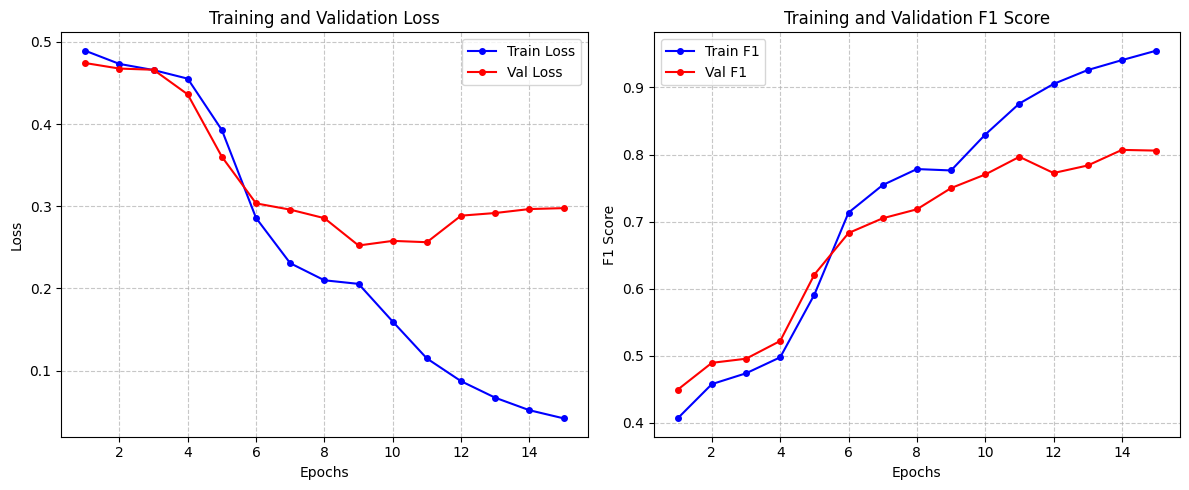

📉 Learning curves saved to learning_curve.png


In [23]:
plot_learning_curves(history)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

✅ Loaded model from 'best_phobert_factcheck_v4.pt'
   Saved at Global Epoch 14 | Phase 3
   Val F1 = 0.8069 | Val Loss = 0.2966


🔍 Inference: 100%|██████████| 56/56 [00:36<00:00,  1.54it/s]



🏆 Test Macro F1: 0.7171
              precision    recall  f1-score   support

   SUPPORTED     0.7747    0.7110    0.7415       353
         NEI     0.8479    0.8361    0.8420       360
     REFUTED     0.5215    0.6229    0.5677       175

    accuracy                         0.7444       888
   macro avg     0.7147    0.7233    0.7171       888
weighted avg     0.7545    0.7444    0.7480       888

📊 Avg Attention Weights:
   Context 1: 0.3488
   Context 2: 0.3378
   Context 3: 0.3133


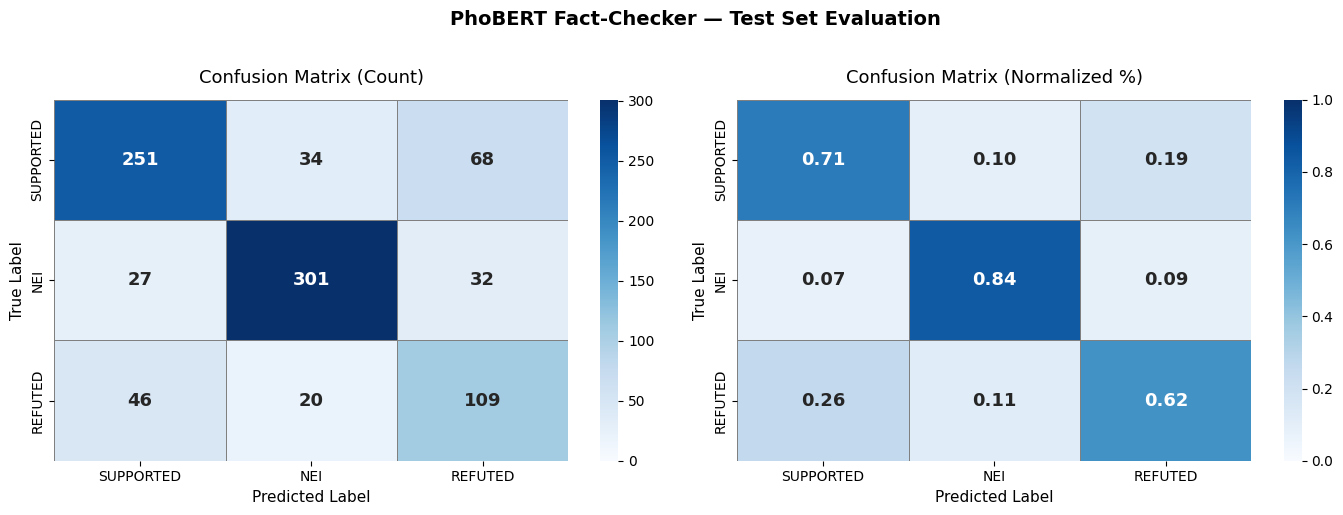

📊 Confusion matrix saved to 'confusion_matrix_test.png'


In [24]:
# =====================================================
# 9. INFERENCE & CONFUSION MATRIX
# =====================================================

import seaborn as sns
from sklearn.metrics import confusion_matrix

LABEL_NAMES = ["SUPPORTED", "NEI", "REFUTED"]

# ---------------------------------------------------
# 9.1. Load model đã lưu
# ---------------------------------------------------

def load_best_model(config, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = PhoBERTFactChecker(
        model_name=config['model_name'],
        num_classes=config['num_classes'],
        dropout_prob=config['dropout_prob']
    )

    checkpoint = torch.load("best_model_3_6_7.pt", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()

    print(f"✅ Loaded model from '{config['save_path']}'")
    print(f"   Saved at Global Epoch {checkpoint['global_epoch']} | Phase {checkpoint['phase']}")
    print(f"   Val F1 = {checkpoint['val_f1']:.4f} | Val Loss = {checkpoint['val_loss']:.4f}")
    return model, device


# ---------------------------------------------------
# 9.2. Inference trên toàn bộ test set
# ---------------------------------------------------

@torch.no_grad()
def run_inference(model, dataloader, device):
    """Chạy inference, trả về predictions, labels, attention weights."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    all_attn = []

    for batch in tqdm(dataloader, desc="🔍 Inference"):
        input_data = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        labels = batch['label']

        logits, attn_weights = model(
            input_ids_1=input_data['input_ids_1'], attention_mask_1=input_data['attention_mask_1'],
            input_ids_2=input_data['input_ids_2'], attention_mask_2=input_data['attention_mask_2'],
            input_ids_3=input_data['input_ids_3'], attention_mask_3=input_data['attention_mask_3'],
        )

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=-1)

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        all_attn.extend(attn_weights.cpu().numpy())

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_probs),
        np.array(all_attn)
    )


# ---------------------------------------------------
# 9.3. Vẽ Confusion Matrix
# ---------------------------------------------------

def plot_confusion_matrix(y_true, y_pred, label_names=LABEL_NAMES,
                          save_path="confusion_matrix.png", normalize=True):
    """
    Vẽ confusion matrix đẹp với seaborn.
    normalize=True → hiển thị tỉ lệ %, dễ so sánh khi data imbalanced.
    """
    cm = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, norm, title_suffix in zip(
        axes,
        [False, True],
        ["(Count)", "(Normalized %)"]
    ):
        if norm:
            cm_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            fmt = ".2f"
            vmax = 1.0
        else:
            cm_plot = cm
            fmt = "d"
            vmax = cm.max()

        sns.heatmap(
            cm_plot,
            annot=True,
            fmt=fmt,
            cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names,
            linewidths=0.5,
            linecolor='gray',
            vmin=0,
            vmax=vmax,
            ax=ax,
            annot_kws={"size": 13, "weight": "bold"}
        )
        ax.set_title(f"Confusion Matrix {title_suffix}", fontsize=13, pad=12)
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label", fontsize=11)
        ax.tick_params(axis='both', labelsize=10)

    plt.suptitle("PhoBERT Fact-Checker — Test Set Evaluation", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Confusion matrix saved to '{save_path}'")
    return cm


# ---------------------------------------------------
# 9.4. Chạy toàn bộ pipeline inference
# ---------------------------------------------------

def evaluate_on_test(config):
    # Load model
    model, device = load_best_model(config)

    # Load test dataset & dataloader
    test_data = load_json_data(config['test_path'])
    if test_data is None:
        print("❌ Không tìm thấy test data.")
        return

    test_dataset = FactCheckingDataset(test_data, config['model_name'], config['max_length'])
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'] * 2,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    # Inference
    preds, labels, probs, attn_weights = run_inference(model, test_loader, device)

    # Metrics
    test_f1 = f1_score(labels, preds, average='macro')
    report = classification_report(labels, preds, target_names=LABEL_NAMES, digits=4)
    print(f"\n{'='*60}")
    print(f"🏆 Test Macro F1: {test_f1:.4f}")
    print(f"{'='*60}")
    print(report)

    # Attention weights trung bình
    mean_attn = attn_weights.mean(axis=0)
    print(f"📊 Avg Attention Weights:")
    for i, w in enumerate(mean_attn):
        print(f"   Context {i+1}: {w:.4f}")

    # Confusion matrix
    cm = plot_confusion_matrix(labels, preds, save_path="confusion_matrix_test.png")

    return {
        'preds': preds,
        'labels': labels,
        'probs': probs,
        'attn_weights': attn_weights,
        'f1': test_f1,
        'report': report,
        'confusion_matrix': cm
    }



# ---------------------------------------------------
# RUN
# ---------------------------------------------------

results = evaluate_on_test(CONFIG)
